In [28]:
import numpy as numpy
import pandas as pd
from sklearn.model_selection import train_test_split # Para dividir os dados
from sklearn.linear_model import LinearRegression    # O nosso modelo preditivo
from sklearn.metrics import mean_absolute_error, r2_score # Para avaliar o erro do modelo
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
dataL = pd.read_csv('imobLimpo.csv')

In [7]:
dataL.head()

,Area_SqFt,Rooms,Build_Year,Location,Street_Type,Furnishing,Property_Type,Has_Pool,Price
0,2473.192784,4.0,1992,Jaipur,Residential Lane,Furnished,Apartment,No,568486.0
1,2353.472711,4.0,2006,Indore,Corner Plot,Unfurnished,Apartment,Yes,577214.0
2,2212.222005,3.0,2012,Jaipur,Highway Facing,Semi-Furnished,Duplex,No,581300.0
3,2823.886596,6.0,1993,Lucknow,Main Road,Unfurnished,Villa,Yes,794614.0
4,1869.648721,5.0,2012,Jaipur,Corner Plot,Semi-Furnished,Apartment,No,493086.0


# modelo de regressao linear

In [20]:
import threading
# Divisao do dataset para regressao

X = dataL[['Area_SqFt']]
y = dataL['Price']

#dividindo treino de previsao

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Total de imóveis para Treino: {len(X_train)}")
print(f"Total de imóveis para Teste: {len(X_test)}")


Total de imóveis para Treino: 821
Total de imóveis para Teste: 206


In [21]:
modelo_lr = LinearRegression()

modelo_lr.fit(X_train, y_train)

print(f"Por cada metro quadrado a mais, o modelo acha que o preço sobe: R$ {modelo_lr.coef_[0]:.2f}")

Por cada metro quadrado a mais, o modelo acha que o preço sobe: R$ 167.93


In [24]:
# testando modelo de previsao

y_pred = modelo_lr.predict(X_test)

#Avaliação

mae= mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"💰 Erro Médio Absoluto (MAE): R$ {mae:,.2f}")
print(f"📊 R-quadrado (R²): {r2:.2%}")

💰 Erro Médio Absoluto (MAE): R$ 54,811.36
📊 R-quadrado (R²): 73.95%


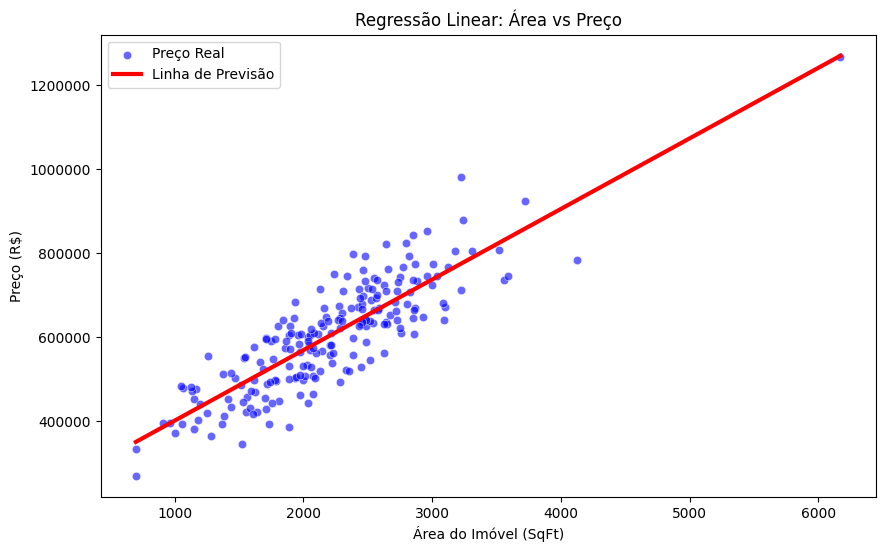

In [29]:
plt.figure(figsize=(10, 6))

# 1. Plotando os pontos reais (usamos os dados de teste para ser justo)
# Os pontos azuis são os preços reais que os imóveis custaram
sns.scatterplot(x=X_test['Area_SqFt'], y=y_test, color='blue', alpha=0.6, label='Preço Real')

# 2. Plotando a linha de previsão do modelo
# A linha vermelha representa o que o modelo chuta que o preço vai ser baseado na área
sns.lineplot(x=X_test['Area_SqFt'], y=y_pred, color='red', linewidth=3, label='Linha de Previsão')

plt.title('Regressão Linear: Área vs Preço')
plt.xlabel('Área do Imóvel (SqFt)')
plt.ylabel('Preço (R$)')
plt.ticklabel_format(style='plain', axis='y') # Tira a notação científica do eixo Y
plt.legend()
plt.show()
